# MAST parameter matching

Loads the mesh built by `MAST_mesh_generator.ipynb`, sets up a TokaMaker object on it, and pulls experimental shot diagnostics from FAIR-MAST as the starting point for matching experimental initial conditions and profiles into the TokaMaker+TORAX coupling.

## FAIR-MAST client

In [1]:
# Only legacy MAST shots (campaigns M5-M9, 2004-2013)
import numpy as np
import requests
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

BASE_URL = 'https://mastapp.site'

In [2]:
def openShotGroup(shotId, group, level=1):
    """
    Opens a diagnostic group (amc, ayc, ane, efm, summary, etc) for a shot,
    download of pulse only happen upon a read
    """
    path = f'json/shots/{shotId}' if level == 1 else f'json/level2/shots/{shotId}'
    try:
        response = requests.get(f'{BASE_URL}/{path}')
        response.raise_for_status()
        shot = response.json()
        shotUrl = shot['url'].replace('s3:/', shot['endpoint_url'])
        return xr.open_zarr(shotUrl, group=group)
    except requests.RequestException as e:
        print(f'failed to fetch shot {shotId}: {e}')
        return None

## Load the mesh into TokaMaker

In [3]:
import os
import sys

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh

shot_id = 30421

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('MAST_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Release version:  v26.6

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  9.355E+00
    # of points  =    7275
    # of edges   =   21714
    # of cells   =   14440
    # of boundary points =     108
    # of boundary edges  =     108
    # of boundary cells  =     108
  Resolution statistics:
    hmin =  3.000E-03
    hrms =  4.130E-02
    hmax =  1.740E-01
  Surface grounded at vertex    1021



## Known parameters

In [ ]:
efm = openShotGroup(shot_id, 'efm', level=1)
validTimes = efm['time'].values[~np.isnan(efm['plasma_current_c'].values)]
refTime = float(validTimes[0])
equilibrium = efm.sel(time=refTime, method='nearest')

print('Ip', float(equilibrium['plasma_current_c']))
print('xpoint1', float(equilibrium['xpoint1_rc']), float(equilibrium['xpoint1_zc']))
print('xpoint2', float(equilibrium['xpoint2_rc']), float(equilibrium['xpoint2_zc']))
print('qpsi', equilibrium['qpsi_c'].values)
print('ffprime', equilibrium['ffprime'].values)
print('pprime', equilibrium['pprime'].values)

ayc = openShotGroup(shot_id, 'ayc', level=1)
teValidTimeMask = ~np.isnan(ayc['te'].values).all(axis=1)
thomsonValidTimes = ayc['time'].values[teValidTimeMask]
thomsonRefTime = float(thomsonValidTimes[np.argmin(np.abs(thomsonValidTimes - refTime))])
thomson = ayc.sel(time=thomsonRefTime, method='nearest')
print('Te', thomson['te'].values)
print('ne', thomson['ne'].values)

act = openShotGroup(shot_id, 'act', level=1)
ti = act['pla_temperature'].sel(time=refTime, method='nearest')
print('Ti', ti.values)

anb = openShotGroup(shot_id, 'anb', level=1)
power = anb['tot_sum_power'].sel(time=refTime, method='nearest')

pf_active = openShotGroup(shot_id, 'pf_active', level=2)
print('P4 lower nTurns', pf_active['p4_lower_r'].size)
print('P4 upper nTurns', pf_active['p4_upper_r'].size)
print('P5 lower nTurns', pf_active['p5_lower_r'].size)
print('P5 upper nTurns', pf_active['p5_upper_r'].size)

## Derived parameters

In [ ]:
def buildGeqdsk(eq):
    """
    Builds a dict matching read_eqdsk()'s keys from an efm equilibrium slice.
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    lcfsR, lcfsZ = eq['lcfs_r'].values, eq['lcfs_z'].values
    lcfsValid = ~np.isnan(lcfsR) & ~np.isnan(lcfsZ)
    return {
        'nr': len(gridR),
        'nz': len(gridZ),
        'rdim': float(gridR.max() - gridR.min()),
        'zdim': float(gridZ.max() - gridZ.min()),
        'rleft': float(gridR.min()),
        'zmid': float((gridZ.max() + gridZ.min()) / 2.0),
        'rcentr': float(eq['rvtor']),
        'bcentr': float(eq['bvac_val']),
        'raxis': float(eq['magnetic_axis_r']),
        'zaxis': float(eq['magnetic_axis_z']),
        'psimag': float(eq['psi_axis']),
        'psibry': float(eq['psi_boundary']),
        'ip': float(eq['plasma_current_c']),
        'fpol': eq['fpsi_c'].values,
        'pres': eq['ppsi_c'].values,
        'ffprim': eq['ffprime'].values,
        'pprime': eq['pprime'].values,
        'psirz': eq['psirz'].values[:, validCols],
        'qpsi': eq['qpsi_c'].values,
        'rzout': np.column_stack([lcfsR[lcfsValid], lcfsZ[lcfsValid]]),
        'rzlim': np.column_stack([eq['limiterr'].values, eq['limiterz'].values]),
    }

def psiNormAtMidplane(rQuery, eq):
    """
    Maps real-space midplane R to normalized poloidal flux using the cleaned psirz grid
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    psirzClean = eq['psirz'].values[:, validCols]
    interp = RegularGridInterpolator((gridZ, gridR), psirzClean, bounds_error=False, fill_value=None)
    zAxis = float(eq['magnetic_axis_z'])
    psi = interp(np.column_stack([np.full_like(rQuery, zAxis), rQuery])) # Assume thomson chords at magnetic axis height, replace after asking
    return (psi - float(eq['psi_axis'])) / (float(eq['psi_boundary']) - float(eq['psi_axis']))

def rhoTorNormFromPsiNorm(psiNormQuery, eq):
    """
    rho_tor_norm = sqrt(enclosed toroidal flux / total toroidal flux)
    """
    psiNorm65 = eq['psi_norm'].values
    q = eq['qpsi_c'].values
    torFlux = np.concatenate([[0.0], np.cumsum(0.5 * (q[1:] + q[:-1]) * np.diff(psiNorm65))])
    torFluxNorm = torFlux / torFlux[-1]
    return np.interp(np.clip(psiNormQuery, 0, 1), psiNorm65, torFluxNorm) ** 0.5

def mapThomsonToRho(shotId, refTime, eq):
    thomson = openShotGroup(shotId, 'ayc', level=1).sel(time=refTime, method='nearest')
    r, te, ne = thomson['radius'].values, thomson['te'].values, thomson['ne'].values
    valid = ~np.isnan(r) & ~np.isnan(te) & ~np.isnan(ne)
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq)
    return rho, te[valid], ne[valid]

def gasPuffRate(shotId, coarseDt=0.01):
    """
    Need a particle rate for set_fueling. gas_injection only gives a cumulative
    injected count, resample onto a coarser time grid before differentiating.
    """
    ds = openShotGroup(shotId, 'gas_injection', level=2)
    t, total = ds['time'].values, ds['total_injected'].values
    tCoarse = np.arange(t.min(), t.max(), coarseDt)
    totalCoarse = np.interp(tCoarse, t, total)
    rateCoarse = np.clip(np.gradient(totalCoarse, tCoarse), 0, None)
    return dict(zip(tCoarse.tolist(), rateCoarse.tolist()))

In [ ]:
geqdsk = buildGeqdsk(equilibrium)

# ppsi_c/pprime come from efm sign-flipped as a matched pair
geqdsk['pres'] = -geqdsk['pres']
geqdsk['pprime'] = -geqdsk['pprime']

F0 = float(equilibrium['rvtor'] * equilibrium['bvac_val'])
mygs.setup(order=2, F0=F0)

for name in ['p2_inner_lower', 'p2_inner_upper', 'p2_outer_lower', 'p2_outer_upper', 'p3_lower', 'p3_upper', 'p6_lower', 'p6_upper', 'sol']:
    print(name, 'nTurns', pf_active[f'{name}_r'].size)

# Initial kinetic profiles, Te/ne from Thomson 
rhoInit, teInit, neInit = mapThomsonToRho(shot_id, thomsonRefTime, equilibrium)

gasPuffSTotal = gasPuffRate(shot_id)

print('F0', F0)
print('psirz shape', geqdsk['psirz'].shape, 'nan count', np.isnan(geqdsk['psirz']).sum())
print('rzout', geqdsk['rzout'])
print('pres', geqdsk['pres'])
print('pprime', geqdsk['pprime'])
print('rho_tor_norm', rhoInit)
print('Te on rho grid', teInit)
print('ne on rho grid', neInit)
print('gas puff rate breakpoints', len(gasPuffSTotal))


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.3089999999999999E-003
p2_inner_lower nTurns 12
p2_inner_upper nTurns 12
p2_outer_lower nTurns 8
p2_outer_upper nTurns 8
p3_lower nTurns 8
p3_upper nTurns 8
p6_lower nTurns 4
p6_upper nTurns 4
sol nTurns 656
F0 -0.40025240182876587
psirz shape (65, 65) nan count 0
rzout [[ 0.19634606  0.        ]
 [ 0.20208846  0.0625    ]
 [ 0.2115625   0.12137273]
 [ 0.21210012  0.125     ]
 [ 0.22642982  0.1875    ]
 [ 0.241875    0.23329233]
 [ 0.24800058  0.25      ]
 [ 0.2721875   0.30177993]
 [ 0.27814853  0.3125    ]
 [ 0.3025      0.35108516]
 [ 0.3221909   0.375     ]
 [ 0.3328125   0.3871413 ]
 [ 0.363125    0.41506276]
 [ 0.3934375   0.43484396]
 [ 0.3986797   0.4375    ]
 [ 0.42375     0.4504328 ]
 [ 0.4540625   0.46159238]
 [ 0.484375    0.46895042]
 [ 0.5146875   0.4731632 ]
 [ 0.545       0.47465983]
 [ 0.5753125   0.47371542]
 [ 0.605625    0.47048512]
 [ 0.

P6 upper/lower carry opposite-direction current 

*High performance plasma vertical position control system for upgraded MAST* and *Validation of the static forward Grad-Shafranov equilibrium solvers in FreeGSNKE and Fiesta using EFIT++ reconstructions from MAST-U* says P6 is wired in anti-series

In [ ]:
# TokaMaker_TORAX requires cocos=2 
signIp = np.sign(geqdsk['ip'])
signB0 = np.sign(geqdsk['bcentr'])
signPsi = np.sign(geqdsk['psibry'] - geqdsk['psimag'])

print('coil_sets', mygs.coil_sets)
print('sign Ip', signIp)
print('sign B0', signB0)
print('sign psi_bry - psi_mag', signPsi)

coil_sets {'P2_INNER_LOWER': {'id': 0, 'net_turns': 12.0, 'sub_coils': [{'reg_id': 3, 'coil_id': 0, 'nturns': 12, 'coil_set': 'P2_INNER_LOWER', 'allow_xpoints': False, 'name': 'P2_INNER_LOWER'}]}, 'P2_INNER_UPPER': {'id': 1, 'net_turns': 12.0, 'sub_coils': [{'reg_id': 4, 'coil_id': 1, 'nturns': 12, 'coil_set': 'P2_INNER_UPPER', 'allow_xpoints': False, 'name': 'P2_INNER_UPPER'}]}, 'P2_OUTER_LOWER': {'id': 2, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 5, 'coil_id': 2, 'nturns': 8, 'coil_set': 'P2_OUTER_LOWER', 'allow_xpoints': False, 'name': 'P2_OUTER_LOWER'}]}, 'P2_OUTER_UPPER': {'id': 3, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 6, 'coil_id': 3, 'nturns': 8, 'coil_set': 'P2_OUTER_UPPER', 'allow_xpoints': False, 'name': 'P2_OUTER_UPPER'}]}, 'P3_LOWER': {'id': 4, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 7, 'coil_id': 4, 'nturns': 8, 'coil_set': 'P3_LOWER', 'allow_xpoints': False, 'name': 'P3_LOWER'}]}, 'P3_UPPER': {'id': 5, 'net_turns': 8.0, 'sub_coils': [{'reg_id': 8, 'coil_id': 5, '

Starting non-linear GS solver
     1 -1.5305E+01  2.1651E+01  3.8246E+00  8.2610E-01 -8.3746E-03 -0.0000E+00
     2 -1.1252E+00  3.6064E+00  1.2161E+00  8.1789E-01 -8.9551E-03 -0.0000E+00
     3 -4.9183E+00  6.9613E+00  7.4182E-01  8.2891E-01 -8.3548E-03 -0.0000E+00
     4 -5.6905E+00  7.9072E+00  1.5506E-01  8.3573E-01 -8.4918E-03 -0.0000E+00
     5 -5.3810E+00  7.5621E+00  5.6724E-02  8.3781E-01 -8.5440E-03 -0.0000E+00
     6 -5.4658E+00  7.6781E+00  5.1189E-02  8.3889E-01 -8.5721E-03 -0.0000E+00
     7 -5.4164E+00  7.6265E+00  3.2176E-03  8.3922E-01 -8.5792E-03 -0.0000E+00
     8 -5.4259E+00  7.6411E+00  1.1358E-02  8.3938E-01 -8.5817E-03 -0.0000E+00
     9 -5.4183E+00  7.6335E+00  2.2797E-03  8.3943E-01 -8.5816E-03 -0.0000E+00
    10 -5.4191E+00  7.6352E+00  2.3605E-03  8.3945E-01 -8.5813E-03 -0.0000E+00
    11 -5.4179E+00  7.6341E+00  6.4335E-04  8.3945E-01 -8.5808E-03 -0.0000E+00
    12 -5.4179E+00  7.6343E+00  4.5149E-04  8.3945E-01 -8.5805E-03 -0.0000E+00
    13 -5.4177E+00  7.

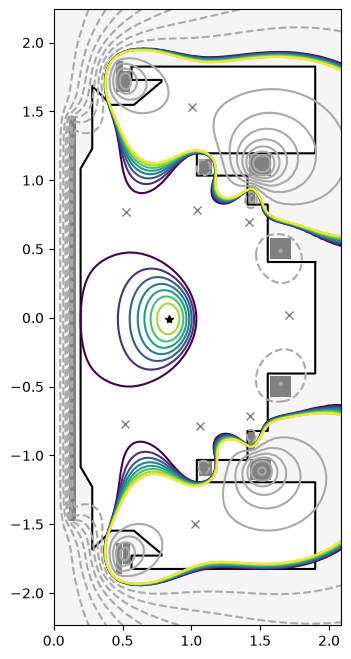

In [ ]:
# regularization pulls coil currents toward zero so the solve is plausible
regTerms = [mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0e-4) for name in mygs.coil_sets]
mygs.set_coil_reg(reg_terms=regTerms)

paxTarget = abs(geqdsk['pres'][0])
mygs.set_targets(Ip=geqdsk['ip'], pax=paxTarget)
mygs.set_isoflux_constraints(geqdsk['rzout'])

rzout = geqdsk['rzout']
r0 = float(equilibrium['magnetic_axis_r'])
z0 = float(equilibrium['magnetic_axis_z'])
a = float((rzout[:, 0].max() - rzout[:, 0].min()) / 2.0)
kappa = float((rzout[:, 1].max() - rzout[:, 1].min()) / (2.0 * a))
mygs.init_psi(r0=r0, z0=z0, a=a, kappa=kappa, delta=0.0)

mygs.settings.maxits = 100
equil, nIts = mygs.solve(return_its=True)
print('converged in', nIts, 'iterations')

stats = mygs.get_stats()
for k, v in stats.items():
    print(f'{k} = {v}')

fig, ax = plt.subplots(figsize=(5, 8))
mygs.plot_machine(fig, ax)
mygs.plot_psi(fig, ax)

## Set up full pulse design with tmtx

In [ ]:
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX

# Seed equilibria
tPulseStart = float(validTimes[0])
tPulseEnd = float(validTimes[-1])
seedTimes = [tPulseStart, 0.15, 0.3, 0.45, tPulseEnd]

mygs.set_coil_bounds({name: [-1.0e7, 1.0e7] for name in mygs.coil_sets})  # matches how OFT ITER example uses loose bounds

In [ ]:
# Generate and save one seed eqdsk per seed time, using experimental EFIT boundary 
# and coil currents.
seedFiles = []
channelToCoilSet = {
    'SOL': 'SOL', 'P2IL FEED': 'P2_INNER_LOWER', 'P2IU FEED': 'P2_INNER_UPPER',
    'P2OL FEED': 'P2_OUTER_LOWER', 'P2OU FEED': 'P2_OUTER_UPPER',
    'P3L FEED': 'P3_LOWER', 'P3U FEED': 'P3_UPPER',
    'P4L FEED': 'P4_LOWER', 'P4U FEED': 'P4_UPPER',
    'P5L FEED': 'P5_LOWER', 'P5U FEED': 'P5_UPPER',
    'P6L': 'P6_LOWER', 'P6U': 'P6_UPPER',
}
for i, seedTime in enumerate(seedTimes):
    seedEq = efm.sel(time=seedTime, method='nearest')
    seedGeqdsk = buildGeqdsk(seedEq)
    seedGeqdsk['pres'] = -seedGeqdsk['pres']

    pfActiveCurrents = openShotGroup(shot_id, 'pf_active', level=2)
    
    regTerms = []
    for channelName, coilSetName in channelToCoilSet.items():
        realCurrentAmps = float(pfActiveCurrents['coil_current'].sel(current_channel=channelName).sel(time=seedTime, method='nearest'))
        netTurns = mygs.coil_sets[coilSetName]['net_turns']
        regTerms.append(mygs.coil_reg_term({coilSetName: 1.0}, target=realCurrentAmps * netTurns, weight=1.0e-2))
    mygs.set_coil_reg(reg_terms=regTerms)

    mygs.set_targets(Ip=seedGeqdsk['ip'], pax=abs(seedGeqdsk['pres'][0]))
    mygs.set_isoflux_constraints(seedGeqdsk['rzout'])

    rzout = seedGeqdsk['rzout']
    r0 = float(seedEq['magnetic_axis_r'])
    z0 = float(seedEq['magnetic_axis_z'])
    a = float((rzout[:, 0].max() - rzout[:, 0].min()) / 2.0)
    kappa = float((rzout[:, 1].max() - rzout[:, 1].min()) / (2.0 * a))
    mygs.solve()

    seedPath = f'seed_{i}.eqdsk'
    mygs.save_eqdsk(seedPath, cocos=2)  # save_eqdsk defaults to cocos=7, TokaMaker_TORAX assumes cocos=2 internally
    seedFiles.append(seedPath)

Starting non-linear GS solver
     1 -6.0832E+01  6.4906E+01  1.2691E-01  8.3396E-01 -9.0198E-03 -0.0000E+00
     2  1.1858E+00  4.6563E+00  1.1967E-02  8.2911E-01 -8.8872E-03 -0.0000E+00
     3 -3.1263E+00  7.1358E+00  5.8938E-03  8.2893E-01 -8.7687E-03 -0.0000E+00
     4 -5.0034E+00  8.3442E+00  8.5195E-03  8.3249E-01 -8.7561E-03 -0.0000E+00
     5 -5.5414E+00  8.7076E+00  7.1909E-03  8.3594E-01 -8.7949E-03 -0.0000E+00
     6 -5.6432E+00  8.7710E+00  4.8602E-03  8.3820E-01 -8.8336E-03 -0.0000E+00
     7 -5.6570E+00  8.7776E+00  3.0700E-03  8.3954E-01 -8.8603E-03 -0.0000E+00
     8 -5.6557E+00  8.7757E+00  1.8870E-03  8.4030E-01 -8.8770E-03 -0.0000E+00
     9 -5.6528E+00  8.7733E+00  1.1352E-03  8.4074E-01 -8.8869E-03 -0.0000E+00
    10 -5.6504E+00  8.7716E+00  6.7897E-04  8.4098E-01 -8.8928E-03 -0.0000E+00
    11 -5.6489E+00  8.7706E+00  3.9976E-04  8.4112E-01 -8.8962E-03 -0.0000E+00
    12 -5.6479E+00  8.7699E+00  2.3265E-04  8.4119E-01 -8.8983E-03 -0.0000E+00
    13 -5.6473E+00  8.

In [ ]:
# Build the coupled object
tmtx = TokaMaker_TORAX(
    t_init=tPulseStart,
    t_final=tPulseEnd,
    eqtimes=seedTimes,
    g_eqdsk_arr=seedFiles,
    tokamaker_obj=mygs,
    tx_dt=0.005,  # MAST pulses run ~0.5s
    tm_times=list(np.linspace(tPulseStart, tPulseEnd, 20)),
)
tmtx.set_TORAX_grid(grid_type='n_rho', grid=51)

In [ ]:
# Sources: Ip, gas puff, NBI
ipTrajectory = {float(t): float(i) for t, i in zip(efm['time'].values[~np.isnan(efm['plasma_current_c'].values)], efm['plasma_current_c'].values[~np.isnan(efm['plasma_current_c'].values)])}
tmtx.set_Ip(ipTrajectory)

tmtx.set_fueling(gas_puff_S_total=gasPuffSTotal, gas_puff_decay_length=0.05)

nbiValid = ~np.isnan(anb['tot_sum_power'].values)
nbiTrajectory = dict(zip(anb['time'].values[nbiValid].tolist(), (anb['tot_sum_power'].values[nbiValid] * 1e6).tolist()))  # MW to W

tmtx.set_heating(generic_heat=nbiTrajectory, generic_heat_loc=0.25, nbi_current=True)  # MAST uses NBI

In [ ]:
sortOrder = np.argsort(rhoInit)
neProfile = {0.0: {float(r): float(n) for r, n in zip(rhoInit[sortOrder], neInit[sortOrder])}}
teProfile = {0.0: {float(r): float(t) for r, t in zip(rhoInit[sortOrder], teInit[sortOrder])}}
tmtx.set_ne(neProfile, right_bc=float(neInit[sortOrder][-1]))
tmtx.set_Te(teProfile, right_bc=float(teInit[sortOrder][-1]))

tmtx.set_Ti({0.0: {0.0: 0.1, 1.0: 0.1}}, right_bc=0.1)  # placeholder flat profile, dont have a usable real one yet

In [ ]:
# Run fly assume Zeff=1 for now
tmtx.set_plasma_composition(main_ion={'D': 1.0}, Zeff=1.0)  # MAST is deuterium only, no tritium

tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)
tmtx.set_TokaMaker_coil_reg()  # defaults to +-45 MA-turns per coil, loose enough not to need real limits for a first test

tmtx.fly(run_name='mast_basic_test')

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/Research/TokaMaker_TORAX_log_mast_basic_test_2026-09-23_180007.log

 TokaMaker_TORAX  
 run_name = mast_basic_test | t=[0.0, 0.6] s | 20 timepoints | dt=0.005 s | max_loop=3

  Initial TORAX relax


ValueError: Initial TORAX relax: first seed EQDSK not valid for TORAX: seed_0.eqdsk